Импорты

In [1]:
import numpy as np
import pandas as pd
import joblib
import optuna
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from category_encoders import TargetEncoder

from utils import (
    load_data, evaluate_model, save_metrics, plot_feature_importance,
    NUMERIC_FEATURES_FULL, CATEGORICAL_FEATURES, MODELS_DIR
)

optuna.logging.set_verbosity(optuna.logging.WARNING)


C:\Users\roman\PycharmProjects\real_estate_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загрузка данных

In [2]:
X_train, X_test, y_train, y_test, y_log_train, y_log_test = load_data()
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Колонки:", list(X_train.columns))


Train: (8819, 12) | Test: (2205, 12)
Колонки: ['area', 'rooms', 'floor', 'total_floors', 'minutes_to_metro', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'is_studio', 'log_area', 'metro_station', 'renovation']


Препроцессор и пайплайн

In [3]:
# Для линейной регрессии используем все числовые признаки, включая log_area
numeric = NUMERIC_FEATURES_FULL

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["renovation"]),
    ("te",  TargetEncoder(cols=["metro_station"], smoothing=10.0), ["metro_station"]),
])

def make_pipeline(alpha: float) -> Pipeline:
    return Pipeline([
        ("prep", preprocessor),
        ("model", Ridge(alpha=alpha, random_state=42)),
    ])


Подбор alpha через Optuna: 50 итераций

In [4]:
def objective(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 1e2, log=True)
    pipe = make_pipeline(alpha)
    # Учим на лог-таргете, метрика — MAE на лог-шкале
    scores = cross_val_score(
        pipe, X_train, y_log_train,
        cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
    )
    return -scores.mean()

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)
best_alpha = study.best_params["alpha"]
print(f"Лучший alpha: {best_alpha:.5f}")


Best trial: 42. Best value: 0.215126: 100%|██████████| 50/50 [00:08<00:00,  6.24it/s]

Лучший alpha: 58.75414


Финальное обучение

In [5]:
final_pipeline = make_pipeline(best_alpha)
final_pipeline.fit(X_train, y_log_train)

# Предсказание на тесте и возврат в исходный масштаб рублей
y_log_pred = final_pipeline.predict(X_test)
y_pred = np.expm1(y_log_pred)

metrics = evaluate_model(y_test, y_pred, "LinearRegression")



=== LinearRegression ===
  MAE  =      14,358,731 руб.
  RMSE =      36,148,490 руб.
  MAPE =          22.10 %
  R2   =         0.7385


Важность признаков через коэффициенты

График сохранён: C:\Users\roman\PycharmProjects\real_estate_ML\reports\feature_importance_linearregression.png


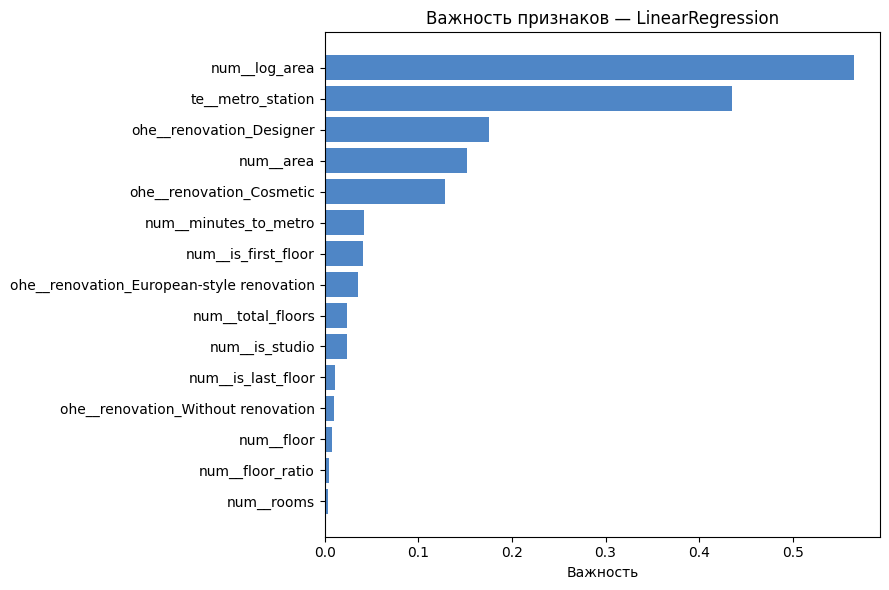

In [6]:
# Получаем имена признаков после препроцессинга
prep = final_pipeline.named_steps["prep"]
model = final_pipeline.named_steps["model"]
feature_names = prep.get_feature_names_out()

importance_df = plot_feature_importance(
    feature_names, np.abs(model.coef_), "LinearRegression", top_n=15
)


Сохранение

In [7]:
joblib.dump(final_pipeline, MODELS_DIR / "linear_regression.pkl")
save_metrics("LinearRegression", metrics, best_params={"alpha": best_alpha})
print("Готово.")


Метрики сохранены в C:\Users\roman\PycharmProjects\real_estate_ML\ml_models\metrics.json
Готово.


Проверка инференса

In [30]:
from inference import predict_linear

example = {
    "area": 38.0,
    "rooms": 1.0,
    "floor": 5.0,
    "total_floors": 15,
    "minutes_to_metro": 20.0,
    "is_studio": 0,
    "metro_station": "Коломенская", "renovation": "Cosmetic",
}
print(f"Предсказание: {predict_linear(example):,.0f} руб.")


Предсказание: 12,300,306 руб.
